In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
!unzip imagewoof200.zip

Archive:  imagewoof200.zip
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00003690.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00009052.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00011152.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00012460.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00017380.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00019830.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00022292.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00025912.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00027492.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00028540.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00029381.JPEG  
  inflating: imagewoof200/test/australian_terrier/ILSVRC2012_val_00029691.JPEG  
 

In [3]:
from pathlib import Path
data_path = Path("")
image_path = data_path / "imagewoof200"

In [4]:
import os

def check_data(dir_path):

  for dirpath, dirnames, filenames in os.walk(dir_path):

    print(f"Number of directories: {len(dirnames)}, Number of images: {len(filenames)} in {dirpath}")


In [5]:
check_data(image_path)

Number of directories: 2, Number of images: 0 in imagewoof200
Number of directories: 10, Number of images: 0 in imagewoof200/train
Number of directories: 0, Number of images: 200 in imagewoof200/train/border_terrier
Number of directories: 0, Number of images: 200 in imagewoof200/train/golden_retriever
Number of directories: 0, Number of images: 200 in imagewoof200/train/old_english_sheepdog
Number of directories: 0, Number of images: 200 in imagewoof200/train/dingo
Number of directories: 0, Number of images: 200 in imagewoof200/train/australian_terrier
Number of directories: 0, Number of images: 200 in imagewoof200/train/rhodesian_ridgeback
Number of directories: 0, Number of images: 200 in imagewoof200/train/english_foxhound
Number of directories: 0, Number of images: 200 in imagewoof200/train/beagle
Number of directories: 0, Number of images: 200 in imagewoof200/train/shih_tzu
Number of directories: 0, Number of images: 200 in imagewoof200/train/samoyed
Number of directories: 10, Num

In [6]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [7]:
train_dir

PosixPath('imagewoof200/train')

In [8]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [9]:
manual_transforms = transforms.Compose({
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
})

In [10]:
NUM_WORKERS = os.cpu_count()

def createDataLoaders(train_dir:str, test_dir: str, transform: transforms.Compose, batch_size:int, num_workers: int = NUM_WORKERS):
    train_dataset = datasets.ImageFolder(root = train_dir, transform=transform, target_transform=None)
    test_dataset = datasets.ImageFolder(root = test_dir, transform=transform)

    classNames = train_dataset.classes

    train_dataloader = DataLoader(dataset= train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
    test_dataloader = DataLoader(dataset= test_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

    return train_dataloader, test_dataloader, classNames



In [11]:
train_dataloader, test_dataloader, classNames = createDataLoaders(train_dir = train_dir, test_dir = test_dir, transform = manual_transforms, batch_size = 32, num_workers = NUM_WORKERS)

In [12]:
train_dataloader

In [13]:
classNames

['australian_terrier',
 'beagle',
 'border_terrier',
 'dingo',
 'english_foxhound',
 'golden_retriever',
 'old_english_sheepdog',
 'rhodesian_ridgeback',
 'samoyed',
 'shih_tzu']

In [14]:
import torchvision

In [15]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT

In [16]:
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [17]:
auto_transforms = weights.transforms()

In [18]:
train_dataloader, test_dataloader, classNames = createDataLoaders(train_dir = train_dir, test_dir = test_dir, transform = auto_transforms, batch_size = 32, num_workers = NUM_WORKERS)

In [19]:
import torch
torch.cuda.is_available()

True

In [20]:
!nvidia-smi

Sat Apr 25 08:38:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [21]:
import torch
print(torch.__version__)

2.10.0+cu128


In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [23]:
model = torchvision.models.efficientnet_b0(weights = weights)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 165MB/s]


In [24]:
!pip install torchinfo

In [25]:
from torchinfo import summary

In [26]:
summary(model = model,
        input_size = (32, 3, 224, 224),
        col_names = ["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 224, 224]         [32, 1000]                --                        True
├─Sequential: 1-1                                       [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        True
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]         [32, 32, 112, 112]        --                        True
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]         [32, 32, 112, 112]        864                       True
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        [32, 32, 112, 112]        64                        True
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        [32, 32, 112, 112]        --                        --
│    └─Sequential: 2-2  

In [27]:
for params in model.features.parameters():
  params.requires_grad = False

summary(model = model,
        input_size = (32, 3, 224, 224),
        col_names = ["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 224, 224]         [32, 1000]                --                        Partial
├─Sequential: 1-1                                       [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        False
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]         [32, 32, 112, 112]        --                        False
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]         [32, 32, 112, 112]        (864)                     False
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        [32, 32, 112, 112]        (64)                      False
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        [32, 32, 112, 112]        --                        --
│    └─Sequential

In [28]:
class_count = len(classNames)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, out_features=class_count, bias=True)
).to(device)

In [29]:
summary(model = model,
        input_size = (32, 3, 224, 224),
        col_names = ["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 224, 224]         [32, 10]                  --                        Partial
├─Sequential: 1-1                                       [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        False
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]         [32, 32, 112, 112]        --                        False
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]         [32, 32, 112, 112]        (864)                     False
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        [32, 32, 112, 112]        (64)                      False
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        [32, 32, 112, 112]        --                        --
│    └─Sequential

In [30]:
from torch import nn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [31]:
def trainStep(
        model: torch.nn.Module,
        dataloader: torch.utils.data.DataLoader,
        loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer,
        device: torch.device,
    ):

    model.train()

    train_loss = 0
    train_acc = 0

    for batch, (X, y) in enumerate(dataloader):

        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        predictedClass = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (predictedClass == y).sum().item() / len(y_pred)

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    return train_loss, train_acc

def testStep(
        model: torch.nn.Module,
        dataloader: torch.utils.data.DataLoader,
        loss_fn: torch.nn.Module,
        device: torch.device,
    ):

    model.eval()
    test_loss = 0
    test_acc = 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):

            X, y = X.to(device), y.to(device)

            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            test_loss += loss.item()

            testPredictedLabels = y_pred.argmax(dim=1)
            test_acc += (testPredictedLabels == y).sum().item() / len(y_pred)

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

    return test_loss, test_acc

def train(
        model: torch.nn.Module,
        train_dataloader: torch.utils.data.DataLoader, test_dataloader: torch.utils.data.DataLoader,
        device: torch.device,
        optimizer: torch.optim.Optimizer, loss_fn: torch.nn.Module = nn.CrossEntropyLoss(), epochs: int = 10
    ):

    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = trainStep(model= model, dataloader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, device=device)
        test_loss, test_acc = testStep(model= model, dataloader=test_dataloader, loss_fn=loss_fn, device=device)

        print(f"Epoch: {epoch + 1}, Train loss: {train_loss}, Test loss: {test_loss}, Train acc: {train_acc}, Test acc: {test_acc}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results


In [32]:
results = train(
    model = model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    device=device,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=20
)

Epoch: 1, Train loss: 1.3973710480190458, Test loss: 0.75000981092453, Train acc: 0.6750992063492064, Test acc: 0.8541666666666666
Epoch: 2, Train loss: 0.6963595497229743, Test loss: 0.5444384177525838, Train acc: 0.84375, Test acc: 0.8708333333333333
Epoch: 3, Train loss: 0.544326799256461, Test loss: 0.44940297106901805, Train acc: 0.8725198412698413, Test acc: 0.8854166666666666
Epoch: 4, Train loss: 0.45047635289411697, Test loss: 0.43353814582029976, Train acc: 0.8849206349206349, Test acc: 0.8791666666666667
Epoch: 5, Train loss: 0.3901868401065705, Test loss: 0.39244825740655265, Train acc: 0.8953373015873016, Test acc: 0.8916666666666667
Epoch: 6, Train loss: 0.36810633374585044, Test loss: 0.38577301800251007, Train acc: 0.9112103174603174, Test acc: 0.8895833333333333
Epoch: 7, Train loss: 0.34378428757190704, Test loss: 0.37703343530495964, Train acc: 0.9126984126984127, Test acc: 0.89375
Epoch: 8, Train loss: 0.31159387055843596, Test loss: 0.38394730488459267, Train acc: 

In [33]:
from PIL import Image
import matplotlib.pyplot as plt
from typing import List, Tuple

In [40]:
def transform_predict(model: torch.nn.Module,
                      image_path:str,
                      class_names:List[str],
                      image_size: Tuple[int, int] = (224, 224),
                      transform: torchvision.transforms = None,
                      device: torch.device = device
                      ):

  img = Image.open(image_path)

  if transform is not None:
    image_transform = transform
  else:
    image_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

  model.to(device)

  model.eval()
  with torch.inference_mode():

    transformed_image = image_transform(img).unsqueeze(dim=0)
    target_image_pred = model(transformed_image.to(device))

  target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
  target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

  plt.figure()
  plt.imshow(img)
  plt.title(f"Pred: {class_names[target_image_pred_label]}, Prob: {target_image_pred_probs.max():.0%}")


In [41]:
custom_image_path = data_path / "golden_img.webp"

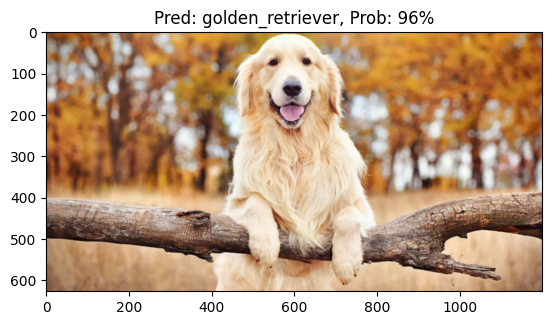

In [42]:
transform_predict(model, custom_image_path, classNames)